In [10]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%load_ext autoreload
%autoreload 2

import os
os.chdir(os.path.expanduser("/workspaces/capstone_imperial_ml_ai/src"))

from ml.data import DataLoader, TransformUtils
from ml.plot import PlotUtils
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
function = "function_3"
X, y = DataLoader.load_all_function_data(function_name=function)

Loaded data from /workspaces/capstone_imperial_ml_ai/data/initial_data/function_3
Input shape: (15, 3), Output shape: (15,)
Loaded submission data from /workspaces/capstone_imperial_ml_ai/data/submissions/function_3.json
Submission input shape: (1, 3), output shape: (1,)


(np.int64(6),
 array([0.15183663, 0.43999062, 0.99088187]),
 np.float64(0.3989255131463011))

(array([ 6,  8, 12]),
 array([0.39892551, 0.13146061, 0.11804826]),
 array([[0.15183663, 0.43999062, 0.99088187],
        [0.74691195, 0.28419631, 0.22629985],
        [0.04680895, 0.23136024, 0.77061759]]))

(array([0.17152521, 0.24211446, 0.53490572, 0.49258141, 0.13462167,
        0.34552327, 0.15183663, 0.64550284, 0.74691195, 0.17047699,
        0.22054934, 0.66601366, 0.04680895, 0.60009728, 0.96599485,
        0.736361  ]),
 array([0.1121222 , 0.08796286, 0.11141465, 0.03483531, 0.04800758,
        0.11062091, 0.39892551, 0.11386851, 0.13146061, 0.09418956,
        0.04694741, 0.10596504, 0.11804826, 0.03637783, 0.05675837,
        0.00134347]))

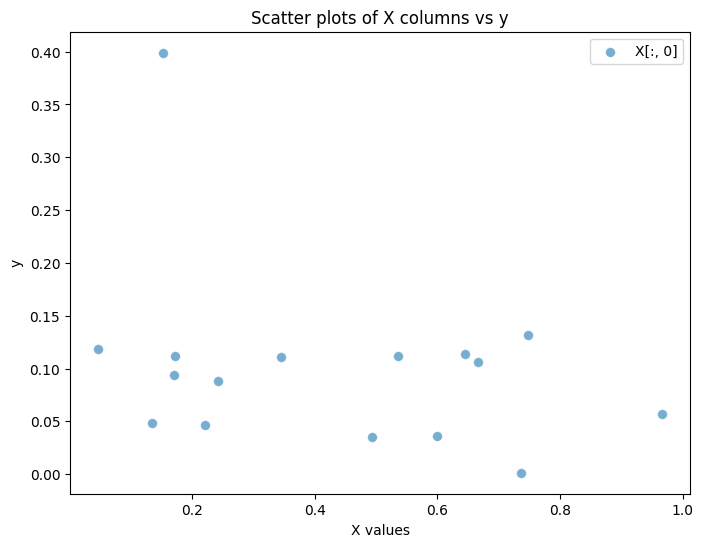

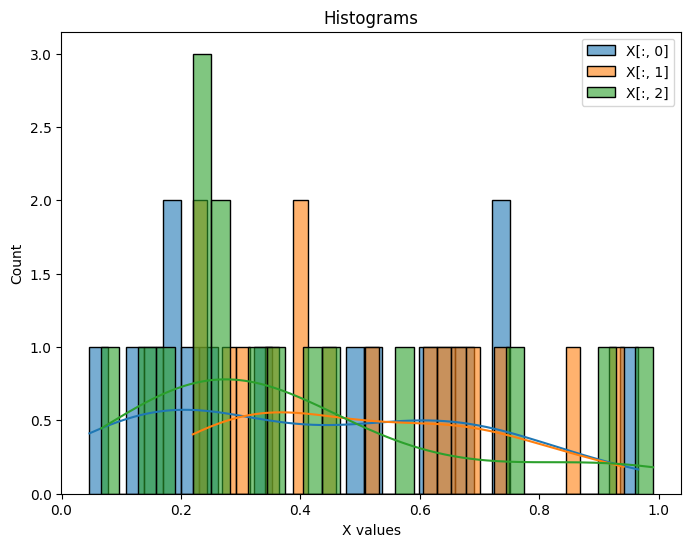

In [39]:
# X
y=np.abs(y)
np.argmax(y), X[np.argmax(y)], np.max(y)
top3_indices = np.argsort(y)[-3:][::-1]
top3_values = y[top3_indices]
top3_X = X[top3_indices]
top3_indices, top3_values, top3_X
X[:, 0], y
PlotUtils.scatter(X=X[:,0].reshape(-1, 1), y=y)
PlotUtils.histogram(data=X)

In [39]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import make_pipeline

def scale(X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    
    x_scaler = StandardScaler(with_mean=True, with_std=True)
    y_scaler = RobustScaler()

    x_log = X #np.log(np.abs(X))
    y_log = np.log(np.abs(y)).reshape(-1, 1) # np.log(np.abs(y)).reshape(-1, 1)
    X_transformed = x_scaler.fit_transform(x_log)
    y_transformed = y_scaler.fit_transform(y_log).ravel()
    
    return X_transformed, y_transformed


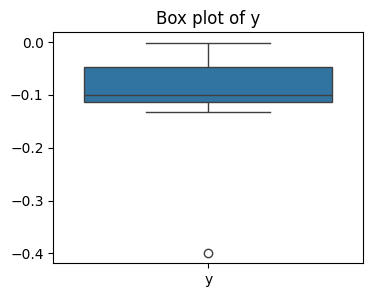

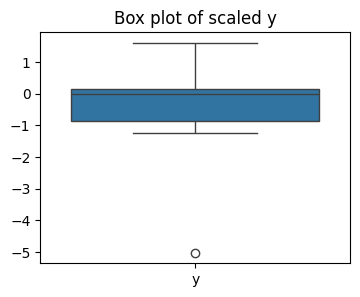

In [40]:
PlotUtils.box(y, figsize=(4, 3), title='Box plot of y')
X_transformed, y_transformed = scale(X, y)
PlotUtils.box(y_transformed, figsize=(4, 3), title='Box plot of scaled y')